# Analysis of PELSA peptidomics data (Li et al, 2025)

## Study background

PELSA [1] is a novel proteomic method to investigate protein-ligand interactions through limited proteolysis. In a nutshell, proteins in solution (typically a cellular lysate) are briefly (typically between 1 and 4 minutes, depending on the specific protocol) treated with the protease trypsin at very high enzyme : substrate ratio (typically 1:2). Trypsin cuts the protein at K and R residues, but digesting very briefly means that only surface exposed K/R sites are actually cut. The critical assumption is that, if a ligand (such as a small molecule) is bound to the protein surface, it stablizes the surrounding protein region and digestion is momentarily slowed. It is worth noting that this is not strictly confined to actual steric blockage, but stablizing effects that extend beyond the ligand's footprint. The key to PELSA is that, when a ligand is present, K/R sites around the binding site are cut at slower rate than if the ligand is not present. If digestion is allowed to proceed for too long, this dynamic effect vanishes as the entire protein gets digested. However, the short digestion time means that peptides which are dynamically stabilized (i.e. ligand-adjacent) will appear as less abundant than their unbound control counterparts. We replicate the original publication's analysis of samples treated with Staurosporine, a pan-kinase binder, and its comparison against DMSO treated samples and visualize the regulation of kinase targets.

## Key proteomics methods and considerations

| Challenge | Why It Matters | Our Approach |
|-----------|---------------|--------------|
| **Missing values** | Proteomics data is ~20-50% missing (MNAR) | Evaluate whether imputation strategies improve results |
| **Dynamic range** | Precursors span 6+ orders of magnitude | Log-transform intensities |
| **Data layers** | Measurement is in precursors, but readout of regulated proteins is preferred | Evaluate published aggregation on UniProt ID and evaluate aggregation directly on gene name |


## References

- [1]: Li, Kejia, et al. "A peptide-centric local stability assay enables proteome-scale identification of the protein targets and binding regions of diverse ligands." Nature Methods 22.2 (2025): 278-282.
- [2]: Ammar, Constantin, et al. "Tree-based quantification infers proteoform regulation in bottom-up proteomics data." bioRxiv (2025): 2025-03.
- [3]: Limpa: https://github.com/SmythLab/limpa
- [4]: Li, Kejia, et al. "High-throughput peptide-centric local stability assay extends protein-ligand identification to membrane proteins, tissues, and bacteria." bioRxiv (2025): 2025-04.
- [5]: MuData: https://github.com/scverse/mudata
- [6]: MuLink: https://github.com/lucas-diedrich/mulink

## Analysis

In [ ]:
%load_ext autoreload
%autoreload 2

import tempfile
import pandas as pd
import numpy as np
import logging
import alphapepttools as apt
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

logger = logging.getLogger(__name__)

### 1. Data loading
#### 1.1. Preparing the dataset using `alphapepttools` loaders and AnnData factory. 

For this study, the relevant files were obtained from study's PRIDE-repository (https://www.ebi.ac.uk/pride/archive/projects/PXD034606) and processed with DIANN 2.1.0. and a human spectral library. The resulting long-format precursor table is available through `alphapepttools`' data module. In addition, corresponding sample metadata has been added to differentiate Staurosporine-treated from control samples. Below is the list of .raw files which were processed for this notebook:

- LKJ_20211007_480_Hela_stau_0uM_1.raw
- LKJ_20211007_480_Hela_stau_0uM_2.raw
- LKJ_20211007_480_Hela_stau_0uM_3.raw
- LKJ_20211007_480_Hela_stau_0uM_4.raw
- LKJ_20211007_480_Hela_stau_20uM_1.raw
- LKJ_20211007_480_Hela_stau_20uM_2.raw
- LKJ_20211007_480_Hela_stau_20uM_3.raw
- LKJ_20211007_480_Hela_stau_20uM_4.raw

We have to extract protein-level intensities and precursor-level intensities from this dataset using the `alphapepttools.io.AnnDataFactory` class. The resulting AnnData object contains protein-group or precursor quantities and any number of feature-metadata columns (for example, protein groups may have genes as secondary annotation, precursors may have protein groups and genes as secondary annotation). Note that the names we use below to refere to columns are not actual DIANN fields. `read_psm_table` runs `alphabase`'s loaders under the hood, which standardize column names and sequence annotation syntax across all supported search engines.

In [ ]:
# Download the data using the alphapepttools data module
report_path = apt.data.get_data("pelsa_report_diann", output_dir=tempfile.mkdtemp())
sample_metadata_path = apt.data.get_data("pelsa_metadata", output_dir=tempfile.mkdtemp())

# Get the full report
full_report = pd.read_parquet(report_path)

# AnnDataFactory instance containing precursor level data
# Note that Protein.Ids is not a standardized alphabase column; since we need it for this experiment, we can specify it as a var-column to be retained in the resulting AnnDataFactory object
adata_precursor = apt.io.read_psm_table(
    file_paths=report_path,
    search_engine="diann",
    level="precursors",
    var_columns=["proteins", "genes", "sequence"],
)

/var/folders/2l/hhd_z4hx3070zw8rlj4c3l940000gn/T/tmpvbwoo08x/report.parquet does not yet exist
/var/folders/2l/hhd_z4hx3070zw8rlj4c3l940000gn/T/tmpvbwoo08x/report.parquet successfully downloaded (70.8467435836792 MB)
/var/folders/2l/hhd_z4hx3070zw8rlj4c3l940000gn/T/tmpjaeejucy/iteration_L_literature_reprocessing_PELSA_samplemap.csv does not yet exist
/var/folders/2l/hhd_z4hx3070zw8rlj4c3l940000gn/T/tmpjaeejucy/iteration_L_literature_reprocessing_PELSA_samplemap.csv successfully downloaded (0.000179290771484375 MB)


#### 1.2. Adding sample metadata

We focus on Protein Groups and Precursors, and use `pp.add_metadata()` to merge the metadata into our AnnData instances. Note that `add_metadata` does not just concatenate shape-matched tables to data, but checks for matching indices. The advantage of this is that the same `AnnData` instance can be reannotated with multiple metadata tables which don't have to match the data in shape or order. 

Tip: Since the matching index is a prerequisite, it is sometimes helpful to map actual file names to metadata by a mapping dictionary as shown below. Generally, it is always preferred to set up metadata such that individual samples are already identified by their rawfile names, but in practice this is often not the case, necessitating a mapping step on some unique sample ID, derived from the rawfile name on the data side, and from the metadata columns on the metadata side.

In [ ]:
sample_metadata = pd.read_csv(sample_metadata_path)
display(sample_metadata)

# Create a unique identifier for each row in the sample metadata by combining the plate and running_count columns
sample_metadata["sample"] = sample_metadata["plate"] + "_" + sample_metadata["running_count"].astype(str)

# Create a mapping from the unique identifier to the original index in the adata_protein.obs_names
run_name_map = {"_".join(k.split("_")[-2:]): k for k in adata_precursor.obs_names}
print(run_name_map)

# Replace the index of the sample metadata with the unique identifier and map it to the original index in adata_protein.obs_names
sample_metadata.index = sample_metadata["sample"].map(run_name_map)

,running_count,plate,treatment,instrument
0,1,0uM,CTRL,E480
1,2,0uM,CTRL,E480
2,3,0uM,CTRL,E480
3,4,0uM,CTRL,E480
4,1,20uM,Stauro,E480
5,2,20uM,Stauro,E480
6,3,20uM,Stauro,E480
7,4,20uM,Stauro,E480


{'0uM_1': 'LKJ_20211007_480_Hela_stau_0uM_1', '0uM_2': 'LKJ_20211007_480_Hela_stau_0uM_2', '0uM_3': 'LKJ_20211007_480_Hela_stau_0uM_3', '0uM_4': 'LKJ_20211007_480_Hela_stau_0uM_4', '20uM_1': 'LKJ_20211007_480_Hela_stau_20uM_1', '20uM_2': 'LKJ_20211007_480_Hela_stau_20uM_2', '20uM_3': 'LKJ_20211007_480_Hela_stau_20uM_3', '20uM_4': 'LKJ_20211007_480_Hela_stau_20uM_4'}


In [ ]:
# Add the metadata to the AnnData instance
adata_precursor = apt.pp.add_metadata(adata_precursor, sample_metadata, axis=0)

#### 1.3. Log2-transformation of proteomics data

We log2-transform our data, but keep the untransformed values in a separate layer called 'raw'. Due to underlying averaging operations, calculations like Coefficient of Variation (CV) should always be done on the non-log-transformed values (computing the mean of logged values carries different statistical implications than taking the mean of untransformed values).

In [ ]:
# First, move the original data to a new layer called "raw" to preserve it before log transformation
adata_precursor.layers["raw"] = adata_precursor.X.copy()

# Apply log-transformation. Note that the nanlog function automatically handles zeros and other invalid values, and prints a small summary to inform about special values encountered during the transformation.
apt.pp.nanlog(adata_precursor)

### 2. Perform basic EDA on protein and precursor data

#### 2.1. Coefficient of Variation analysis

In proteomics, we commonly compare different sample groups using significance tests such as (but not limited to) the two-sided, two-sample independent Student's t-test. It gives us a t-value, which can be interpreted as a standardized fold change between sample groups - standardized, because a normalization for sample-size and variance is baked into the formula. 

$$t = \frac{\bar{X}_1 - \bar{X}_2}{s_p \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}}$$

with the pooled standard deviation $s_p$ given as

$$s_p = \sqrt{\frac{(n_1 - 1)s_1^2 + (n_2 - 1)s_2^2}{n_1 + n_2 - 2}}$$


The resulting t-value, plus a known t-distribution are used to compute the p-value, which is commonly interpreted as "the probability of seeing a difference as extreme or more extreme than the one we see, if we assume that both sample groups come from the same underlying population". A common threshold for significance is set at 0.05, though applications of thresholds vary based on the actual experiment and whether it is more costly to have false-negatives or false-positives. 

- **This means that having high intra-group variance, i.e. high variation within the group directly reduces the power of our t-test.**

Therefore, we must check whether intra-group variance levels are acceptable, commonly done by assessing the *Coefficient of Variation* or *CV*:

$$CV(\%) = \frac{\sigma}{\mu} \times 100\%$$

where $\sigma$ or $s$ denote the population or sample (in practice mostly sample) standard deviation and $\mu$ or $\bar{x}$ denote the population or sample (in practice mostly sample) mean.

- **Note that it is critical to compute CVs on actual intensities, not log-transformed values. Log-transformation breaks the proportional relationship between mean and standard deviation by effectively stabilizing the standard deviation, which causes the SD/mean ratio to shrink as the mean grows, resulting in misleading CVs\***

**\*** For example, the two groups [80, 100, 120] and [8000, 10000, 12000] have means of 100 and 10000, standard deviations of 20 and 2000 and therefore CVs of 20 % and 20 %, respectively. If we log2-transform the values to [6.322, 6.644, 6.907] and [12.966, 13.288, 13.551], the respective means become 6.624 and 13.268, the sample standard deviations become 0.293 and 0.293, and therefore the respective CVs are 0.044 and 0.022 --> the second group appears as more "precise" just from log-transforming.

---

Since PELSA-assay precursor fold changes are generally smaller than e.g. pulldowns, it is especially important to control the spread of replicates. In other words, too high CVs will drown out the signal and cause high numbers of non-significant precursor fold-changes. 
We run `AlphaPeptTools`' `coefficient_of_variation` function with specified sample groups to get the CVs of both treatments**



In [ ]:
adata_precursor = apt.metrics.coefficient_of_variation(
    adata=adata_precursor,
    group_column="treatment",
    key_added="cv_treatment",
    layer="raw",
    copy=True,
    min_valid=2,
)

Note: When there are multiple sample groups to compute CVs on, the `coefficient_of_variation` function adds the results to `AnnData`'s `.varm` dictionary. The advantage of this approach is that `.var` does not get polluted with many different, sample-group dependent column names. Instead, the columns of the dataframe stored in `.varm` correspond to the actual sample groups, and we can get the whole dataframe containing the CVs back by simply calling `adata.varm[<key>]`, where `<key>`means the `key_added` argument of `coefficient_of_variation`, which defaults to `cv`.

We use `alphapepttools`' plotting syntax to generate a stylized panel with violin plots for sample group feature CVs, and to assess the median intensity of all features across samples.

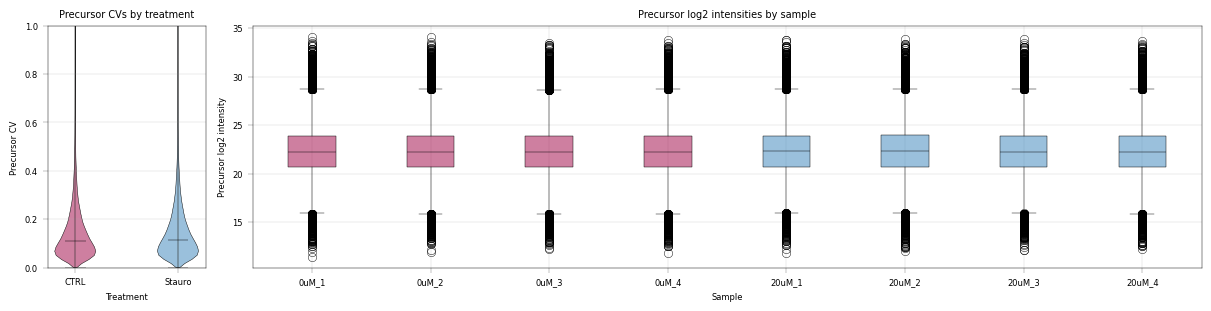

In [ ]:
# Generate an AxisManager object ('axm') which is essentially matplotlib subplots with consistent styling and a iterator properties.
# We can jump to the next subplot axis using axm.next(), or we can navigate to a specific plot using numpy-like indexing, e.g. axm[0, 1] for the first row and second column.
fig, axm = apt.pl.create_figure(1, 2, figsize=(12, 3), gridspec_kwargs={"width_ratios": [0.5, 3]})

# Define color dictionary for the different treatments
color_dict = {
    "CTRL": apt.pl.BaseColors.get("red"),
    "Stauro": apt.pl.BaseColors.get("blue"),
}

# Map the sample names to their respective colors based on treatment
sample_color_dict = {
    sample: color_dict[treatment]
    for sample, treatment in zip(adata_precursor.obs_names, adata_precursor.obs["treatment"], strict=False)
}

plot_data = {
    "precursor": adata_precursor,
}

for readout, adata in plot_data.items():
    # Jump to the first subplot for the CV plots
    ax = (
        axm.next()
    )  # note that 'ax' is a vanilla matplotlib axis object, so we can call any suitable matplotlib function on it
    ax.set_ylim(0, 1)

    apt.pl.violinplot(
        ax=ax,
        data=adata.varm["cv_treatment"],
        direct_columns=["CTRL", "Stauro"],
        color_dict=color_dict,
    )

    apt.pl.label_axes(
        ax=ax,
        xlabel="Treatment",
        ylabel=f"{readout.capitalize()} CV",
        title=f"{readout.capitalize()} CVs by treatment",
    )

    # Second subplot for the boxplots of log2 intensities by sample
    ax = axm.next()
    apt.pl.boxplot(
        ax=ax,
        data=adata.T,
        direct_columns=adata.obs_names.tolist(),
        color_dict=sample_color_dict,
    )

    # Modify ax to process x ticks to fit the plot better
    xtick_labels = [item.get_text() for item in ax.get_xticklabels()]  # Get xtick labels directly from axes
    xtick_labels = [
        "_".join(x.split("_")[-2:]) for x in xtick_labels
    ]  # Shorten the xtick labels to make them more readable
    _ = ax.set_xticklabels(xtick_labels)  # Set the new xtick labels

    apt.pl.label_axes(
        ax=ax,
        xlabel="Sample",
        ylabel=f"{readout.capitalize()} log2 intensity",
        title=f"{readout.capitalize()} log2 intensities by sample",
    )

    # save figure
    apt.pl.save_figure(
        fig=fig,  # Note that here we're using the whole figure to whose axes we added our plots
        filename="pelsa_quantities_overview.svg",
        output_dir="./example_outputs",
    )

### 3. Perform differential expression analysis on precursors

Peptides from the stablized protein regions are expected to appear downregulated. We perform comparative differential expression analysis: 

- On the one hand, we evaluate "vanilla" independent two-sample t-test. 
- On the other, we employ `alphapepttools`' wrapper of `AlphaQuant`[2], a differential expression method specially adapted for mass-spectrometry proteomics data. 
- Additionally, we examine a Python-implementation of the popular *Limma* package's Empirical Bayes moderated ttest, which is more sophisticated than a simple ttest but considerably faster and more lightweight than alphaquant.

We want to retain the original AnnData object's feature-level metadata in our differential expression results, which can be accomplished by joining the `var` object to the results.

#### 3.1 Considerations for missing values

in practice, differential expression analyses face challenges from missing values: on one hand, losing too many replicates means a feature is dropped and lost to follow up analyses. On the other hand, if imputation is used, features that may be noisy or spurious end up in the final results, which is especially problematic for low input experiments with an enrichment setup: in these experiments, a feature may be expected to drop completely in treatment conditions (e.g. pulldown enrichment or genomic knockout), which would justify imputation of missing values with some kind of baseline. However, if intensities approach the limit of detection (LOD) of an instrument, features may also be missing not at random (MNAR) because of low abundance. Blanket imputation brings back "the good and the bad": both downregulated and lowly abundant, highly variable features. 

**in practice**, whether or not to impute depends on the experimental setup and the question asked from the data. For PELSA, the standard practice of filtering for 100 % data completeness has emerged as a practical way to reduce false positives, at the cost of some true regulated hits. More sophisticated imputation methods that aim to model missingness[3] may help alleviate this tradeoff in future analyses

In [ ]:
comparison = ("Stauro", "CTRL")

#### 3.2 Two-sample independent two-sided t-test

In [ ]:
# Vanilla ttest on peptide data
ttest_peptide_results = apt.tl.diff_exp_ttest(
    adata=adata_precursor,
    between_column="treatment",
    comparison=comparison,
    min_valid_values=4,  # this implementation of ttest allows for setting a minimum amount of required valid values within each group
    equal_var=False,
)
ttest_peptide_results = ttest_peptide_results.join(adata_precursor.var, how="left")

Comparing groups: Stauro vs CTRL


#### 3.3 Two-sample independent two-sided Empirical Bayes Moderated t-test

In [ ]:
# Run Limma Empirical Bayes moderated ttest on peptides: alphapepttools inmoose
# This implementation requires 100 % data completeness, i.e. 4/4 values present per feature per condition
ebayes_peptide_results = apt.tl.diff_exp_ebayes(
    adata=adata_precursor,
    between_column="treatment",
    comparison=comparison,
)[1]
ebayes_peptide_results = ebayes_peptide_results.join(adata_precursor.var, how="left")

INFO:alphapepttools.tl.diff_exp.ebayes:Running Limma eBayes differential expression analysis via inmoose
INFO:alphapepttools.tl.diff_exp.ebayes:Comparing levels: Stauro (treatment) vs CTRL (control)
INFO:root:pp.filter_data_completeness(): drop 23133 / 91803 features with >0 missing values.
INFO:alphapepttools.tl.diff_exp.ebayes:Computing contrast: condition[Stauro]-condition[CTRL]
INFO:alphapepttools.tl.diff_exp.ebayes:Design matrix dimensions: 8 samples x 2 groups
INFO:alphapepttools.tl.diff_exp.ebayes:Expression matrix dimensions: 68670 proteins x 8 samples


#### 3.4 Tree-based differential quantification

In [ ]:
# AlphaQuant ttest on full search engine output (takes approx. 3-4 minutes on a M2 MacBook Pro. Set "REPROCESS" flag to True to re-run, otherwise cached data will be used)
REPROCESS = False

if REPROCESS:
    comparison_key, alphaquant_results = apt.tl.diff_exp_alphaquant(
        adata=adata_precursor,
        report=full_report,
        between_column="treatment",
        comparison=comparison,
        valid_values_filter_mode="either",
        min_valid_values=3,
        plots="hide",
    )
    alphaquant_peptide_results = alphaquant_results["peptide"]
    alphaquant_peptide_results.to_pickle("./../example_data/notebook_02_alphaquant_peptide_results.pkl")
else:
    logger.info(" --> Using cached AlphaQuant results")
    alphaquant_peptide_results = pd.read_pickle("./../example_data/notebook_02_alphaquant_peptide_results.pkl")

INFO:__main__: --> Using cached AlphaQuant results


Alphaquant results are saved into a dictionary based on the quantification level:

- results
  - protein level results
  - proteoform level results
  - peptide level results

### 3.5 Custom precursor aggregation

In order to go from precursor to protein-level annotation, we perform an aggregation step similar to the original publication: For each protein, the peptide with the highest significance is assigned its gene name. This effectively converts a dataset of precursors into a dataset of unique genes. 
We perform the same aggregation in our preprocessing here by implementing a custom aggregation function.

In [ ]:
def top_peptides_to_proteins(
    ttest_df: pd.DataFrame,
    y_score_column: str = "-log10(p_value)",
    id_column: str = "protein",
) -> pd.DataFrame:
    """Convert peptide level t-test results to protein level by taking the top peptide per protein."""
    ttest_df = ttest_df.copy()
    return ttest_df.sort_values(y_score_column, ascending=False).groupby(id_column).first().reset_index()


aq_gene_table = top_peptides_to_proteins(alphaquant_peptide_results, id_column="protein")
eb_gene_table = top_peptides_to_proteins(ebayes_peptide_results, id_column="genes")
tt_gene_table = top_peptides_to_proteins(ttest_peptide_results, id_column="genes")

### 3.6 Kinase annotation

Since Staurosporine is a pan-kinase inhibitor and we are interested in recovering its targets, we have to annotate all kinases in the data in order to visualize them and perform kinase enrichment scoring. Therefore, we load a table from Gerard et al. [4] (http://www.kinhub.org/kinases.html) and transfer the gene-level annotations to our data. 

In [ ]:
def annotate_kinases(
    ttest_df: pd.DataFrame,
    kinase_table_path: str,
    gene_id_column: str = "gene",
) -> list:
    """Assign str value for kinase/no kinase based on publication data:

    Manning, Gerard, et al. "The protein kinase complement of the human genome." Science 298.5600 (2002): 1912-1934.,
    table from: http://www.kinhub.org/kinases.html

    """
    ttest_df = ttest_df.copy()
    kinase_table = pd.read_excel(kinase_table_path)
    kinase_list = kinase_table["HGNC Name"].tolist()
    kinase_dict = dict(zip(kinase_list, ["kinase"] * len(kinase_list), strict=False))

    ttest_df["kinase_status"] = ttest_df[gene_id_column].map(kinase_dict).fillna("other")
    return ttest_df


# Download the kinase table using the alphapepttools data module
kinase_path = apt.data.get_data("kinase_table")

tt_gene_table = annotate_kinases(tt_gene_table, kinase_path, "genes")
eb_gene_table = annotate_kinases(eb_gene_table, kinase_path, "genes")
aq_gene_table = annotate_kinases(aq_gene_table, kinase_path, "protein")

/Users/vincenthbrennsteiner/Documents/mann_labs/_git_repositories/alphapepttools/docs/notebooks/studies/kinome_table.xlsx already exists (0.06418609619140625 MB)


### 3.7 Custom Kinase Enrichment Score:

In the main publication [1] and its follow-up [4], a kinase score is implemented to assess the sensitivity and specificity of the assay. This score derives from the fact that, in the ideal case we should only see kinase peptides being regulated by treatment with a kinase-binder. In practice, there are off-targets, i.e. peptides/proteins that appear as downregulated even though they are not kinases. The score is the ratio of downregulated (log2fc < 0) kinases/non-kinases at 80 % specificity when ranking by -log10(p_value). 

#### 3.7.1 Kinase Score intuition
Imagine a boundary moving down from the highest point in the left half of the volcanoplot. Each time the boundary passes a point, we record if the point is a kinase or a non-kinase. When the ratio of passed kinases / passed non-kinases becomes smaller than 0.8 we state that 80 % specificity is reached. However many kinases we have up to this point is our score.

In [ ]:
def kinase_score(
    ttest_df: pd.DataFrame,
    id_col: str,
    score_column: str = "-log10(p_value)",
    max_candidates: int = 500,
    threshold: float = 0.8,
) -> dict | None:
    """Perform kinase scoring analysis per HT-Pelsa.

    1. Sort peptides by -log10(significance) (score_column) descending
    2. Consider only regulated peptides, i.e. log2fc < 0
    3. Iterate through ranks, calculating the cumulative kinase fraction
         (number of kinases / total number of peptides)
    4. Stop when kinase fraction drops below min_kinase_pct or max_candidates is reached

    """
    ttest_df = ttest_df.copy()
    print(
        f"Total unique kinases in the dataset: {ttest_df.loc[ttest_df['kinase_status'] == 'kinase', id_col].nunique()}"
    )

    # Restrict to downregulated peptides
    ttest_df = ttest_df[ttest_df["log2fc"] < 0]
    print(
        f"Total unique kinases in the downregulated dataset: {ttest_df.loc[ttest_df['kinase_status'] == 'kinase', id_col].nunique()}"
    )

    # Rank peptides by score
    ttest_df = ttest_df.sort_values(score_column, ascending=False).reset_index(drop=True)
    ttest_df["rank"] = ttest_df.index + 1

    # Iterate through ranks and record the kinase fraction
    def _kinase_fraction(df: pd.DataFrame) -> float:
        kinase_count = df[df["kinase_status"] == "kinase"].shape[0]
        total_count = df.shape[0]
        return kinase_count / total_count if total_count > 0 else np.nan

    kinase_fractions = []
    for n in range(1, len(ttest_df) + 1):
        subset = ttest_df.head(n)
        kinase_fraction = _kinase_fraction(subset)
        score_threshold = subset[score_column].iloc[-1]
        kinase_fractions.append(
            {
                "rank": n,
                "kinase_fraction": kinase_fraction,
                "score_threshold": score_threshold,
                "n_kinases": subset[subset["kinase_status"] == "kinase"].shape[0],
                "n_total": subset.shape[0],
            }
        )

        if n >= max_candidates and kinase_fraction < threshold:
            break

    kinase_fraction_df = pd.DataFrame(kinase_fractions)

    # Determine score based on specificity threshold
    above_threshold = kinase_fraction_df[kinase_fraction_df["kinase_fraction"] >= threshold]
    optimal_row = above_threshold.iloc[-1] if not above_threshold.empty else None
    if optimal_row is None:
        print("No suitable threshold found.")
        return None

    return {
        "threshold": optimal_row["score_threshold"],
        "n_candidates": optimal_row["rank"],
        "n_kinases": optimal_row["n_kinases"],
        "n_non_kinases": optimal_row["n_total"] - optimal_row["n_kinases"],
        "kinase_percentage": optimal_row["kinase_fraction"],
    }

### 3.8 Volcano plot of differentially regulated genes

`alphapepttools` offers a layered, matplotlib-based plotting syntax that allows for quick and flexible generation of volcanoplots, or any kind of layered plot in general (see `tutorials/tutorial_02_basic_plotting_workflows.ipynb` for reference). The key to this kind of visualization are hierarchical layers that specify which points should be plotted on top, specified by the `layers` argument of `alphapepttools.pl.volcano`. 

In [ ]:
# As before, we establish uniform coloring across all plots
color_dict = {
    "kinase": apt.pl.BaseColors.get("red"),
    "other": apt.pl.BaseColors.get("grey"),
}

#### 3.8.1 t-test results + kinase scoring

Total unique kinases in the dataset: 276
Total unique kinases in the downregulated dataset: 212
Kinase scoring threshold at -log10(p_value) = 3.31, covering 105.0 proteins with 84.0 kinases (80.0%)


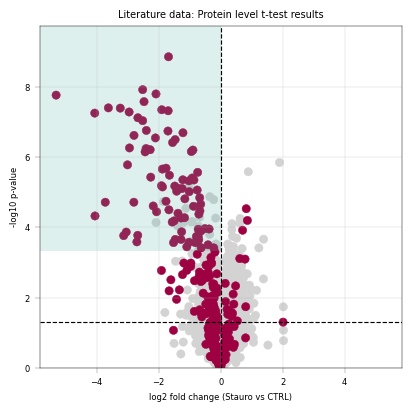

In [ ]:
# Computing the kinase score at a set threshold & small message to summarize the results
ttest_ks_result = kinase_score(tt_gene_table, id_col="genes", threshold=0.8)

print(
    f"Kinase scoring threshold at -log10(p_value) = {ttest_ks_result['threshold']:.2f}, covering {ttest_ks_result['n_candidates']} proteins with {ttest_ks_result['n_kinases']} kinases ({ttest_ks_result['kinase_percentage'] * 100:.1f}%)"
)

fig, axm = apt.pl.create_figure(1, 1, figsize=(4, 4))
ax = axm.next()

apt.pl.volcano(
    ax=ax,
    data=tt_gene_table,
    x_column="log2fc",
    y_column="-log10(p_value)",
    color_dict=color_dict,
    layers=[
        ("kinase_status", "kinase", "kinase"),  # column, filter value, color dict key of top layer
        ("kinase_status", "other", "other"),  # column, filter value, color dict key of second layer
    ],
    x_label_anchors=[-2],
    x_thresholds=(0),
)

apt.pl.label_axes(
    ax=ax,
    xlabel="log2 fold change (Stauro vs CTRL)",
    ylabel="-log10 p-value",
    title="Literature data: Protein level t-test results",
)

# For better visualization, we draw a rectangle to indicate the kinase scoring threshold
left_bound = ax.get_xlim()[0]
upper_bound = ax.get_ylim()[1]
rect = Rectangle(
    xy=(
        left_bound,
        ttest_ks_result["threshold"],
    ),  # Bottom-left corner: x value is the left bound of the plot, y value is the kinase scoring threshold
    width=np.abs(0 - left_bound),  # Width from the left bound to 0, indicating that we focus on downregulated ids
    height=upper_bound - ttest_ks_result["threshold"],  # Height to figure top
    linewidth=2,
    facecolor=apt.pl.BaseColors.get("green", alpha=0.2),
)
ax.add_patch(rect)

# save figure
apt.pl.save_figure(
    fig=fig,  # Note that here we're using the whole figure to whose axes we added our plots
    filename="Literature_PELSA_TTEST_AggProt_Stauro.svg",
    output_dir="./example_outputs",
)

#### 3.8.2 Empirical Bayes moderated ttest (Limma-like) results + kinase scoring

Total unique kinases in the dataset: 253
Total unique kinases in the downregulated dataset: 197
Kinase scoring threshold at -log10(p_value) = 3.57, covering 117.0 proteins with 94.0 kinases (80.3%)


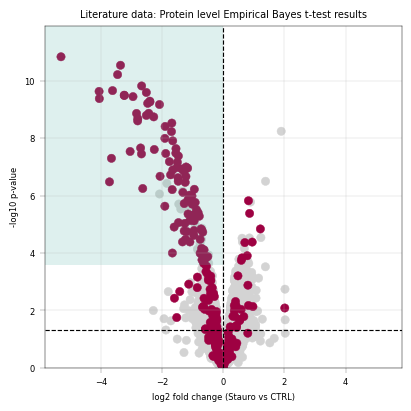

In [ ]:
# Computing the kinase score at a set threshold & small message to summarize the results
ebayes_ttest_ks_results = kinase_score(eb_gene_table, id_col="genes", threshold=0.8)
print(
    f"Kinase scoring threshold at -log10(p_value) = {ebayes_ttest_ks_results['threshold']:.2f}, covering {ebayes_ttest_ks_results['n_candidates']} proteins with {ebayes_ttest_ks_results['n_kinases']} kinases ({ebayes_ttest_ks_results['kinase_percentage'] * 100:.1f}%)"
)

fig, axm = apt.pl.create_figure(1, 1, figsize=(4, 4))
ax = axm.next()

apt.pl.volcano(
    ax=ax,
    data=eb_gene_table,
    x_column="log2fc",
    y_column="-log10(p_value)",
    color_dict=color_dict,
    layers=[
        ("kinase_status", "kinase", "kinase"),  # column, filter value, color name
        ("kinase_status", "other", "other"),
    ],
    label_layers=["kinase_status"],
    x_thresholds=(0),
)

apt.pl.label_axes(
    ax=ax,
    xlabel="log2 fold change (Stauro vs CTRL)",
    ylabel="-log10 p-value",
    title="Literature data: Protein level Empirical Bayes t-test results",
)

# For better visualization, we draw a rectangle to indicate the kinase scoring threshold
left_bound = ax.get_xlim()[0]
upper_bound = ax.get_ylim()[1]
rect = Rectangle(
    xy=(
        left_bound,
        ebayes_ttest_ks_results["threshold"],
    ),  # Bottom-left corner: x value is the left bound of the plot, y value is the kinase scoring threshold
    width=np.abs(0 - left_bound),  # Width from the left bound to 0, indicating that we focus on downregulated ids
    height=upper_bound - ebayes_ttest_ks_results["threshold"],  # Height to figure top
    linewidth=2,
    facecolor=apt.pl.BaseColors.get("green", alpha=0.2),
)
ax.add_patch(rect)

# save figure
apt.pl.save_figure(
    fig=fig,  # Note that here we're using the whole figure to whose axes we added our plots
    filename="Literature_PELSA_EBAYES_TTEST_AggGenes_Stauro.svg",
    output_dir="./example_outputs",
)

#### 3.8.3 Alphaquant results + kinase scoring

Total unique kinases in the dataset: 276
Total unique kinases in the downregulated dataset: 215
Kinase scoring threshold at -log10(p_value) = 3.40, covering 137.0 proteins with 110.0 kinases (80.3%)


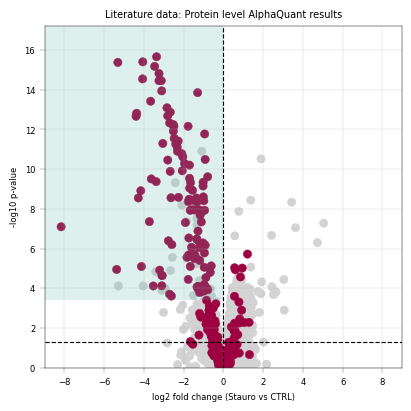

In [ ]:
# Computing the kinase score at a set threshold & small message to summarize the results
aq_ks_result = kinase_score(aq_gene_table, id_col="protein", threshold=0.8)
print(
    f"Kinase scoring threshold at -log10(p_value) = {aq_ks_result['threshold']:.2f}, covering {aq_ks_result['n_candidates']} proteins with {aq_ks_result['n_kinases']} kinases ({aq_ks_result['kinase_percentage'] * 100:.1f}%)"
)

fig, axm = apt.pl.create_figure(1, 1, figsize=(4, 4))
ax = axm.next()

apt.pl.volcano(
    ax=ax,
    data=aq_gene_table,
    x_column="log2fc",
    y_column="-log10(p_value)",
    color_dict=color_dict,
    layers=[
        ("kinase_status", "kinase", "kinase"),  # column, filter value, color name
        ("kinase_status", "other", "other"),
    ],
    x_thresholds=(0),
)

apt.pl.label_axes(
    ax=ax,
    xlabel="log2 fold change (Stauro vs CTRL)",
    ylabel="-log10 p-value",
    title="Literature data: Protein level AlphaQuant results",
)

# For better visualization, we draw a rectangle to indicate the kinase scoring threshold
left_bound = ax.get_xlim()[0]
upper_bound = ax.get_ylim()[1]
rect = Rectangle(
    xy=(
        left_bound,
        aq_ks_result["threshold"],
    ),  # Bottom-left corner: x value is the left bound of the plot, y value is the kinase scoring threshold
    width=np.abs(0 - left_bound),  # Width from the left bound to 0, indicating that we focus on downregulated ids
    height=upper_bound - aq_ks_result["threshold"],  # Height to figure top
    linewidth=2,
    facecolor=apt.pl.BaseColors.get("green", alpha=0.2),
)
ax.add_patch(rect)

# save figure
apt.pl.save_figure(
    fig=fig,  # Note that here we're using the whole figure to whose axes we added our plots
    filename="Literature_PELSA_AlphaQuant_AggProt_Stauro.svg",
    output_dir="./example_outputs",
)

### 3.9 Visualizing the kinase enrichment results compared to literature data

In Figure 2 b of Kejia, Li et al., the number of downregulated vs. kinase proteins at 80 % specificity (as computed above) is given at 135 downregulated candidates and 108 kinase targets. Note that their result were computed using an Empirical Bayes test. We can visualize this data and compare to our `alphapepttools` differential expression data:

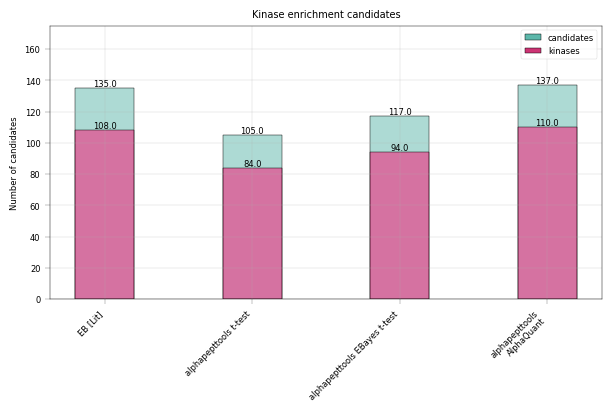

In [ ]:
total_candidates = pd.DataFrame(
    {
        "group": ["EB [Lit]", "alphapepttools t-test", "alphapepttools EBayes t-test", "alphapepttools\nAlphaQuant"],
        "value": [
            135,
            ttest_ks_result["n_candidates"],
            ebayes_ttest_ks_results["n_candidates"],
            aq_ks_result["n_candidates"],
        ],
    }
)

total_kinases = pd.DataFrame(
    {
        "group": ["EB [Lit]", "alphapepttools t-test", "alphapepttools EBayes t-test", "alphapepttools\nAlphaQuant"],
        "value": [108, ttest_ks_result["n_kinases"], ebayes_ttest_ks_results["n_kinases"], aq_ks_result["n_kinases"]],
    }
)

color_dict = {
    "candidates": apt.pl.BaseColors.get("green"),
    "kinases": apt.pl.BaseColors.get("red", lighten=0.1, alpha=0.8),
}

fig, axm = apt.pl.create_figure(1, 1, figsize=(6, 4))

# First, plot the total candidates
ax = axm.next()
ax.set_ylim(0, 175)

apt.pl.barplot(
    ax=ax,
    data=total_candidates,
    grouping_column="group",
    value_column="value",
    color=apt.pl.BaseColors.get("green"),
)

total_candidates["position"] = range(len(total_candidates))
apt.pl.label_plot(
    ax=ax,
    data=total_candidates,
    x_column="position",
    y_column="value",
    label_column="value",
    label_kwargs={"va": "bottom", "ha": "center"},
)

# Then, add the kinases
apt.pl.barplot(
    ax=ax,
    data=total_kinases,
    grouping_column="group",
    value_column="value",
    color=apt.pl.BaseColors.get("red", lighten=0.3),
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

total_kinases["position"] = range(len(total_kinases))
apt.pl.label_plot(
    ax=ax,
    data=total_kinases,
    x_column="position",
    y_column="value",
    label_column="value",
    label_kwargs={"va": "bottom", "ha": "center"},
)

apt.pl.label_axes(
    ax=ax,
    xlabel="",
    ylabel="Number of candidates",
    title="Kinase enrichment candidates",
)

apt.pl.add_legend_to_axes(
    ax=ax,
    levels=color_dict,
)


# save figure
apt.pl.save_figure(
    fig=fig,  # Note that here we're using the whole figure to whose axes we added our plots
    filename="Literature_PELSA_Kinase_Enrichment_Candidates_Comparison.svg",
    output_dir="./example_outputs",
)

### 4. Using combined mdalities to investigate regulated precursors

In peptidomics assays like PELSA, it is highly instructive to check for individual precursors and their location on the target protein. Precursor peptides inside the binding region should experience a larger shift compared to the control condition. `alphapepttools` supports the instantiation of a `MuData` instance [5] with the `MuLink` extension [6]. The latter explicitly links different data heirarcheis with a directed acyclic graph (DAG) structure, meaning that precorsors, proteins and genes can be queried as one and the respective modalities easily extracted into filtered `AnnData` objects.

We start by reading in additional data modalities using the `io.read_psm_table` functionality and annotating the data as previously

In [ ]:
# AnnDataFactory instance containing protein level data
adata_protein = apt.io.read_psm_table(
    file_paths=report_path,
    search_engine="diann",
    level="proteins",
    var_columns=["genes"],
)

# AnnDataFactory instance containing gene level data
adata_gene = apt.io.read_psm_table(
    file_paths=report_path,
    search_engine="diann",
    level="genes",
    var_columns=["genes"],
)

# Add metadata and log-transform
adata_protein = apt.pp.add_metadata(adata_protein, sample_metadata, axis=0)
adata_gene = apt.pp.add_metadata(adata_gene, sample_metadata, axis=0)
adata_protein.layers["raw"] = adata_protein.X.copy()
adata_gene.layers["raw"] = adata_gene.X.copy()
apt.pp.nanlog(adata_protein)
apt.pp.nanlog(adata_gene)

### 4.1 Linking the different modalities into a `MuLink` instance

Since there is a hierarchical relationship between precursors, proteins and genes, and since the respective feature metadata datasets were standardized upon loading with `alphapepttools.io`, registering the datasets into `MuLink` is trivial with the `io.mulink_from_anndatas` function:

In [ ]:
mlink = apt.io.mulink_from_anndatas(
    anndatas={
        "genes": adata_gene,
        "proteins": adata_protein,
        "precursors": adata_precursor,
    }
)

# Inspect the resulting mulink object
display(mlink)

100%|██████████| 2/2 [00:00<00:00,  2.31it/s]
INFO:root:Using custom MuData options in the new context...
INFO:root:Returning to the previously defined options: {'pull_on_update': None}


MuData object with n_obs × n_vars = 8 × 106642
  varp:	'feature_mapping'
  3 modalities
    genes:	8 × 7316
      obs:	'running_count', 'plate', 'treatment', 'instrument', 'sample'
      layers:	'raw'
    proteins:	8 × 7523
      obs:	'running_count', 'plate', 'treatment', 'instrument', 'sample'
      var:	'genes'
      layers:	'raw'
    precursors:	8 × 91803
      obs:	'running_count', 'plate', 'treatment', 'instrument', 'sample'
      var:	'proteins', 'genes', 'sequence'
      varm:	'cv_treatment'
      layers:	'raw'

#### 4.1.1 Filtering the `MuLink` instance

The `MuLink` object can be filtered to obtain e.g. all precursors, proteins and genes belonging to a certain kinases. For demonstration purposes, we select the most downregulated kinase gene that also have at least two associated protein groups:

In [ ]:
# rank downregulated kinases based on decreasing significance
ranked_kinases = (
    eb_gene_table[(eb_gene_table["kinase_status"] == "kinase") & (eb_gene_table["log2fc"] < 0)]
    .sort_values("-log10(p_value)", ascending=False)["genes"]
    .tolist()
)

# Pick the first two that are associated with more than one protein group
selected_kinases_count = 1
selected_kinases = []
for kinase in ranked_kinases:
    associated_proteins = adata_protein.var[adata_protein.var["genes"] == kinase]
    if associated_proteins.shape[0] > 1:
        selected_kinases.append(kinase)
    if len(selected_kinases) >= selected_kinases_count:
        break

print(f"Selected kinases for visualization: {selected_kinases}")

Selected kinases for visualization: ['MAP3K7']


In [ ]:
# Filtering the mulink object to two kinases
mlink_filtered = mlink.link.query.ancestors(selected_kinases)

# Show the features associated with those genes:
display(mlink_filtered)

View of MuData object with n_obs × n_vars = 8 × 18
  varp:	'feature_mapping'
  3 modalities
    genes:	8 × 1
      obs:	'running_count', 'plate', 'treatment', 'instrument', 'sample'
      layers:	'raw'
    proteins:	8 × 2
      obs:	'running_count', 'plate', 'treatment', 'instrument', 'sample'
      var:	'genes'
      layers:	'raw'
    precursors:	8 × 15
      obs:	'running_count', 'plate', 'treatment', 'instrument', 'sample'
      var:	'proteins', 'genes', 'sequence'
      varm:	'cv_treatment'
      layers:	'raw'

#### 4.1.2 Visualizing the linkage between genes - proteins - precursors

The 'core' of a `MuLink` object is the adjacency matrix, which represents how features interact. We can visualize the connection between features by extracting the linkage matrix. The linkage matrix can be extracted from `.varp['feature_mapping']`. It contains all concatenated features on both axes, and each cell is either a `1` or a `0`, depending whether the features interact or not.

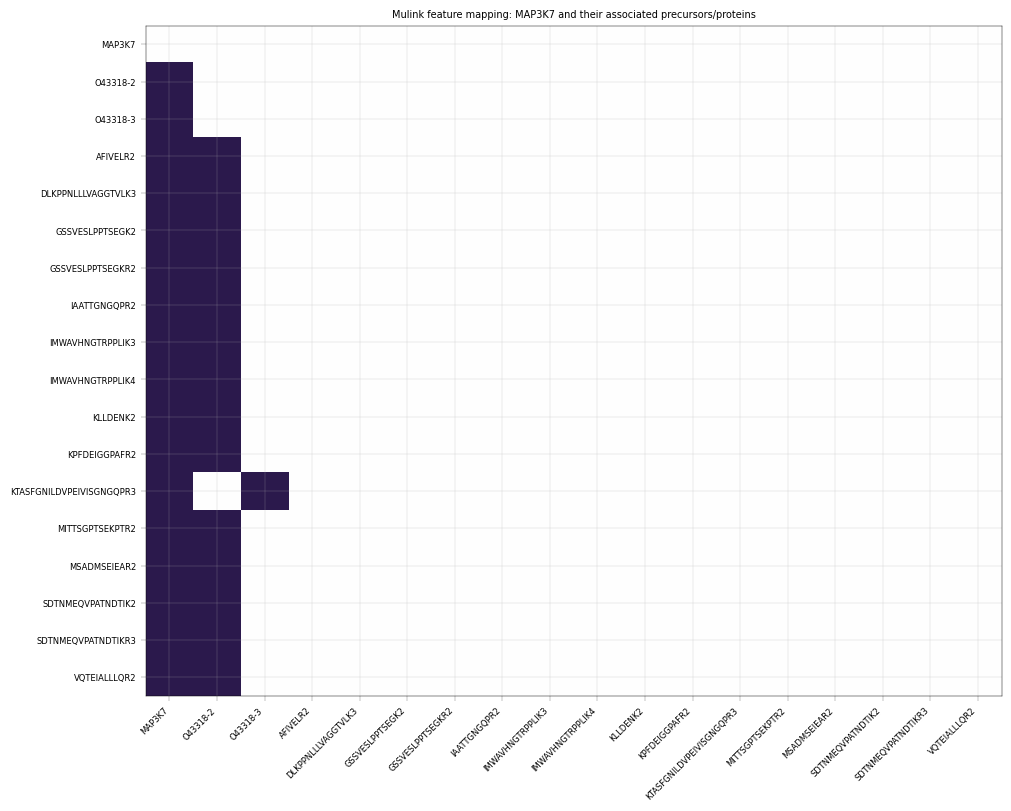

In [ ]:
# extract linkage
linkage = pd.DataFrame(
    data=mlink_filtered.varp["feature_mapping"].toarray(),
    columns=mlink_filtered.var_names,
    index=mlink_filtered.var_names,
)

fig, axm = apt.pl.create_figure(1, 1, figsize=(10, 8))
ax = axm.next()

# Quick heatmap
ax.imshow(linkage, aspect="auto", cmap=apt.pl.BaseColormaps.get("sequential_r"))
ax.set_yticks(range(len(linkage.index)))
ax.set_yticklabels(linkage.index)
ax.set_xticks(range(len(linkage.columns)))
ax.set_xticklabels(linkage.columns, rotation=45, ha="right")

apt.pl.label_axes(
    ax=ax,
    xlabel="",
    ylabel="",
    title=f"Mulink feature mapping: {', '.join(selected_kinases)} and their associated precursors/proteins",
)

plt.show()

--> Note how the respective genes interact with their respectiv eprotein groups, and how their respective precursors are non-overlapping. This is to be expected, as DIA-NN implements protein inference that aims to assign precursors to one protein group.

### 4.2 Performing differential expression on multiple modalities

In addition to our aggregated precursor setting above, it can be instructive to check if the total gene abundance of our selected kinases also change. The setup shown below could be used to extract differential expression data from all modalities: 

In [ ]:
# Performing empirical-Bayes moderated t-tests on all three modalities and saving the results in a dictionary
from alphapepttools.tl.diff_exp.ebayes_expanded import diff_exp_ebayes as diff_exp_ebayes_expanded

diff_exp_results = {}
for modality in ["genes", "proteins", "precursors"]:
    de_results = diff_exp_ebayes_expanded(
        adata=mlink.mod[modality],  # extract modality AnnData directly from MuData object
        between_column="treatment",
        comparison=comparison,
    )

    # Set parent levels (including self) in differential expression tables
    diff_exp_table = de_results[next(iter(de_results.keys()))]
    diff_exp_table = diff_exp_table.join(mlink.mod[modality].var, how="left")

    # fix naming
    if modality == "genes":
        diff_exp_table = diff_exp_table.rename(columns={"protein": "genes"})
    if modality == "proteins":
        diff_exp_table = diff_exp_table.rename(columns={"protein": "proteins"})
    if modality == "precursors":
        diff_exp_table = diff_exp_table.rename(columns={"protein": "precursors"})

    diff_exp_results[modality] = diff_exp_table

    # Annotate with kinase status
    diff_exp_results[modality] = annotate_kinases(diff_exp_results[modality], kinase_path, "genes")

Fitting features: 100%|██████████| 91803/91803 [00:03<00:00, 24571.04it/s]


#### 4.2.1 Repeating the volcanoplots with selected kinase labels

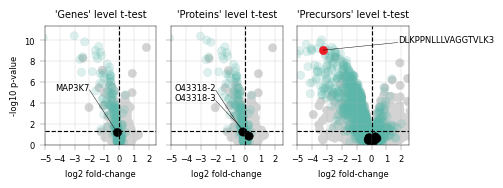

In [ ]:
# fig, axm = apt.pl.create_figure(1, 3, figsize=("1.5", "0.5"), subplots_kwargs={"sharey": True})
fig, axm = apt.pl.create_figure(1, 3, figsize=(125 / 25.4, 45 / 25.4), subplots_kwargs={"sharey": True})

color_dict = {
    "kinase": apt.pl.BaseColors.get("green", alpha=0.2),
    "other": apt.pl.BaseColors.get("grey"),
    "selected": apt.pl.BaseColors.get("black"),
    "focused": "#ed1c24",
}

# select the most significant precursor of the selected ones
precursors = diff_exp_results["precursors"]
selected_precursors = precursors[(precursors["genes"].isin(selected_kinases)) & (~pd.isna(precursors["p_value"]))]
selected_precusror_ids = selected_precursors["precursors"].tolist()
focus_precursors = (
    selected_precursors[selected_precursors["log2fc"] < 0]
    .sort_values("-log10(p_value)", ascending=False)
    .head(1)["precursors"]
    .tolist()[0]
)

for kinase in selected_kinases:
    for modality in ["genes", "proteins", "precursors"]:
        ax = axm.next()

        # If we are plotting precursors, we only want to show the most regulated precursor
        if modality != "precursors":
            layers = [("genes", kinase, "selected")]
            label_layers = ["selected"]
        else:
            layers = [
                ("precursors", focus_precursors, "focused"),
                ("genes", kinase, "selected"),
            ]
            label_layers = ["focused"]

        # Specify visualization layers
        layers += [
            ("kinase_status", "kinase", "kinase"),
            ("kinase_status", "other", "other"),
        ]

        apt.pl.volcano(
            ax=ax,
            data=diff_exp_results[modality],
            x_column="log2fc",
            y_column="-log10(p_value)",
            color_dict=color_dict,
            layers=layers,
            label_layers=label_layers,
            display_id_column=modality,
            x_label_anchors=[1.75] if modality == "precursors" else [-2],
            y_display_start=1 if modality == "precursors" else 0.6,
            y_padding_factor=2,
            x_thresholds=(0),
            xlims=(-5, 2.5),
        )

        apt.pl.label_axes(
            ax=ax,
            xlabel="log2 fold-change",
            ylabel="-log10 p-value" if modality == "genes" else "",
            title=f"'{modality.capitalize()}' level t-test",
        )

        # Prettify x-labels to better granularity: steps of 1
        ax.set_xticks(np.arange(-5, 3, 1))

        # # Turn right spine off for precursor data
        # if modality == "precursors":
        #     ax.spines["right"].set_visible(False)

# save figure
apt.pl.save_figure(
    fig=fig,  # Note that here we're using the whole figure to whose axes we added our plots
    filename="Literature_PELSA_Selected_Kinase_Volcanos.png",
    output_dir="../../assets/pelsa_peptidomics_volcanos",
    transparent=True,
    dpi=300,
)

--> Interestingly, it appears that neither protein group associated with MAP3K7, nor the associated gene is significantly downregulated. However, on the precursor level there is a single precursor that stands out. We can visualize the difference between treatment and control modalities directly from the `MuData` object to inspect the actual values behind the differential expression results:

#### 4.2.2 Extracting differential precursor abundances directly from the `MuData` instance

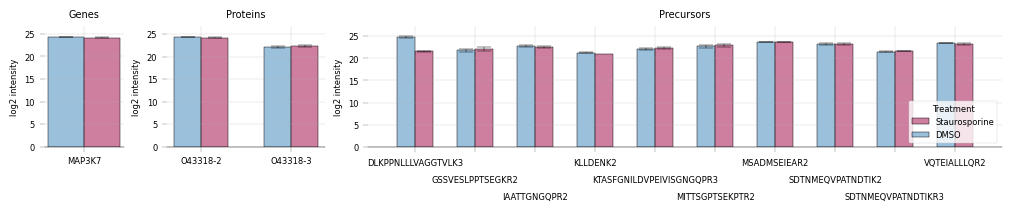

In [ ]:
# boxplots with subgrouing by treatment
fig, axm = apt.pl.create_figure(1, 3, figsize=(10, 2), gridspec_kwargs={"width_ratios": [0.5, 1, 4]})

color_dict = {
    "Stauro": apt.pl.BaseColors.get("red"),
    "CTRL": apt.pl.BaseColors.get("blue"),
}

for modality in ["genes", "proteins", "precursors"]:
    ax = axm.next()

    # Get the modality-specific AnnData object directly from the MuData object
    modality_adata = mlink_filtered.mod[modality]

    # Restrict precursors to those which have a valid log2fc and p-value
    if modality == "precursors":
        modality_adata = modality_adata[:, modality_adata.var_names.isin(selected_precusror_ids)]

    # set limits
    ax.set_ylim(0, np.nanmax(modality_adata.X) * 1.1)

    # join treatement and abundances
    df = (
        modality_adata.to_df()
        .join(modality_adata.obs["treatment"])
        .melt(id_vars="treatment", var_name="feature", value_name="log2_intensity")
    )

    # Number of features
    feature_count = len(modality_adata.var_names.unique())
    apt.pl.barplot(
        ax=ax,
        data=df,
        grouping_column="feature",
        subgroup_column="treatment",
        value_column="log2_intensity",
        color_dict=color_dict,
        width=0.3,
    )

    apt.pl.label_axes(
        ax=ax,
        xlabel="",
        ylabel="log2 intensity",
        title=f"{modality.capitalize()}",
    )

    # Better fit precursor x-ticks: prepend every second one with one \n and every third one with two \n to create visual separation
    if modality == "precursors":
        # Offset ticks
        for i, tick in enumerate(ax.xaxis.get_major_ticks()):
            tick.set_pad(5 + (i % 3) * 12)

        # Add legend
        apt.pl.add_legend_to_axes(
            ax=ax,
            levels={
                "Staurosporine": apt.pl.BaseColors.get("red", alpha=0.5),
                "DMSO": apt.pl.BaseColors.get("blue", alpha=0.5),
            },
            title="Treatment",
            # turn box off
            loc="lower right",
        )

    # Turn off spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # set y-axis ticks in steps of 5
    ax.set_yticks(np.arange(0, np.nanmax(modality_adata.X) * 1.1, 5))

In [ ]:
modality_adata.var_names.unique()

Index(['DLKPPNLLLVAGGTVLK3', 'GSSVESLPPTSEGKR2', 'IAATTGNGQPR2', 'KLLDENK2',
       'KTASFGNILDVPEIVISGNGQPR3', 'MITTSGPTSEKPTR2', 'MSADMSEIEAR2',
       'SDTNMEQVPATNDTIK2', 'SDTNMEQVPATNDTIKR3', 'VQTEIALLLQR2'],
      dtype='object', name='precursor_id')

Remarkably, we see that only a single peptide out of the entire gene appears differentially regulated between the treatment and control condition, meaning that a pure gene-level or protein-level analysis would miss this hit entirely. Therefore, peptidomics analyses stand to benefit significantly from our `MuLink`-powered multi-level analysis.

## Summary

In summary, we saw that `alphapepttools`...

- can swiftly load precursor and protein data into `AnnData` instances
- contains standardized, 'plug and play' modules for proteomics differential expression
- offers strong basic functions but remains easily extendable to custom functions and use-cases, chiefly by
  - Avoiding end-to-end data processing pipelines, instead keeping Python data structures accessible at all times
  - Avoiding end-to-end plotting pipelines, instead keeping Matplotlib axes accessible at all times for customization

### Note:

Access to data structures and plot axes is especially useful in the light of LLM-assisted data analysis, where exact syntax knowledge of e.g. Matplotlib is no longer required. Under these aspects, any abstraction (e.g. via a GUI) is liable to be more limiting than standardized Python objects, the manipulation of which is amply covered by current LLMs. We believe that this mix of strong 'atomic' functions and custom extensions for a given analysis is ideal to handle modern proteomics data analysis in a reproducible & shareable way.